# VPBank Operational-Risk Early-Warning — Anomaly Detection

**Topic 2, VPBank Young Talents 2026.**
All data is **synthetic and illustrative** (see `/data`).

This notebook:
1. Computes the six KRIs from the daily logs (via DuckDB SQL).
2. Sets static warning thresholds using the p95 / baseline+2σ rule.
3. Trains an unsupervised **Isolation Forest** across all KRIs at once.
4. Validates it by **injecting synthetic anomalies** and measuring **recall**.
5. Runs a short **error analysis** (which days it catches / misses).

The three ground-truth outage dates planted by `generate_data.py`
are **2026-02-28, 2026-04-14, 2026-05-31** — the "answer key".


In [31]:
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
DATA = "../data"

# The dates the generator planted as true SYSTEM outages
GROUND_TRUTH = pd.to_datetime(["2026-02-28", "2026-04-14", "2026-05-31"])


## 1. Compute KRIs with SQL (DuckDB reads the CSVs directly)

In [32]:
con = duckdb.connect()

# KRI 1: failure rate (SYSTEM + PARTNER only)
kri1 = con.execute(f'''
    SELECT date,
           ROUND(100.0*(fail_system+fail_partner)/NULLIF(total_tx,0),3) AS fail_rate_pct
    FROM read_csv_auto('{DATA}/transactions_daily.csv')
    ORDER BY date
''').df()

# KRI 3: users with >=3 failed transactions
kri3 = con.execute(f'''
    SELECT date,
           ROUND(100.0*users_3plus_fails/NULLIF(active_users,0),3) AS kri3_users_3fails
    FROM read_csv_auto('{DATA}/transactions_daily.csv')
    ORDER BY date
''').df()

# KRI 5: manual override rate
kri5 = con.execute(f'''
    SELECT date,
           ROUND(100.0*manual_override/NULLIF(total_tx,0),3) AS override_pct
    FROM read_csv_auto('{DATA}/transactions_daily.csv')
    ORDER BY date
''').df()

# KRI 4: eKYC total drop-off
kri4 = con.execute(f'''
    SELECT date,
           ROUND(100.0*(started-completed)/NULLIF(started,0),2) AS ekyc_dropoff_pct
    FROM read_csv_auto('{DATA}/ekyc_daily.csv')
    ORDER BY date
''').df()

# KRI 6: overdue training
kri6 = con.execute(f'''
    SELECT date, overdue_training_pct
    FROM read_csv_auto('{DATA}/hr_daily.csv')
    ORDER BY date
''').df()

kri1.head()


,date,fail_rate_pct
0,2026-01-01,0.973
1,2026-01-02,1.312
2,2026-01-03,1.146
3,2026-01-04,1.384
4,2026-01-05,1.700


### Assemble one KRI table (one row per day)
KRI 2 (velocity) is derived from KRI 1. KRI 3 is computed from the daily count of users with ≥3 fails over active users.

In [33]:
df = kri1.merge(kri3, on="date").merge(kri4, on="date").merge(kri5, on="date").merge(kri6, on="date")
df["date"] = pd.to_datetime(df["date"])
# KRI 2: velocity = today's fail rate / yesterday's
df["velocity"] = (df["fail_rate_pct"] / df["fail_rate_pct"].shift(1)).round(2)
df["velocity"] = df["velocity"].fillna(1.0)

df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()


(180, 7)


,date,fail_rate_pct,kri3_users_3fails,ekyc_dropoff_pct,override_pct,overdue_training_pct,velocity
0,2026-01-01,0.973,0.774,33.07,0.234,7.28,1.00
1,2026-01-02,1.312,0.842,32.21,0.168,7.74,1.35
2,2026-01-03,1.146,0.720,30.38,0.113,7.82,0.87
3,2026-01-04,1.384,0.761,33.54,0.225,8.17,1.21
4,2026-01-05,1.700,0.419,28.97,0.216,8.44,1.23


## 2. Static thresholds — the p95 / baseline+2σ rule

This is exactly the methodology stated on Slide 5: a warning fires at
**baseline + 2σ**, which for roughly normal data is close to the
**95th percentile**. We compute both so the number on the slide is
reproducible, not hand-picked.

In [34]:
def threshold_2sigma(s):
    return round(s.mean() + 2*s.std(), 2)

def threshold_p95(s):
    return round(s.quantile(0.95), 2)

for col in ["fail_rate_pct", "ekyc_dropoff_pct", "override_pct", "velocity"]:
    print(f"{col:20s}  mean+2σ = {threshold_2sigma(df[col]):>7}   "
          f"p95 = {threshold_p95(df[col]):>7}")


fail_rate_pct         mean+2σ =    3.52   p95 =    1.99
ekyc_dropoff_pct      mean+2σ =   48.46   p95 =   46.71
override_pct          mean+2σ =     0.3   p95 =    0.27
velocity              mean+2σ =    3.64   p95 =    1.76


## 3. Isolation Forest across all KRIs at once

The key idea (Slide 9): an anomalous day is one whose *combination* of
KRIs is unusual — even if no single KRI has breached its static limit.
Isolation Forest isolates such points with fewer random splits.

We add **calendar flags** (pay-day, Tet window) so the model can learn
that predictable seasonal spikes are *not* incidents.

In [35]:
feat = df.copy()

# calendar features
feat["day_of_month"] = feat["date"].dt.day
feat["is_payday"] = feat["day_of_month"].isin([5, 20]).astype(int)
day_index = (feat["date"] - feat["date"].min()).dt.days
feat["is_tet"] = ((day_index >= 40) & (day_index <= 46)).astype(int)

FEATURES = ["fail_rate_pct", "kri3_users_3fails", "ekyc_dropoff_pct",
            "override_pct", "velocity", "overdue_training_pct",
            "is_payday", "is_tet"]

X = feat[FEATURES].values

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # expect ~3% of days to be anomalous
    random_state=42,
)
feat["anomaly_score"] = iso.fit_predict(X)      # -1 = anomaly, 1 = normal
feat["score_raw"] = iso.decision_function(X)    # lower = more anomalous

flagged = feat[feat["anomaly_score"] == -1]
print(f"Days flagged as anomalies: {len(flagged)}")
flagged[["date", "fail_rate_pct", "ekyc_dropoff_pct", "score_raw"]]


Days flagged as anomalies: 6


,date,fail_rate_pct,ekyc_dropoff_pct,score_raw
4,2026-01-05,1.700,28.97,-0.018998
42,2026-02-12,2.047,38.96,-0.000654
58,2026-02-28,8.371,38.09,-0.098372
103,2026-04-14,10.404,39.20,-0.143211
139,2026-05-20,2.168,47.62,-0.036942
150,2026-05-31,8.053,42.05,-0.128537


## 4. Validation — did it catch the planted outages?

Because we have no real incident labels, we validate against the
**synthetic anomalies we injected** in the generator. Recall =
(planted outages caught) / (total planted outages).

In [36]:
flagged_dates = set(flagged["date"].dt.normalize())
gt = set(GROUND_TRUTH)

caught = gt & flagged_dates
missed = gt - flagged_dates
false_alarms = flagged_dates - gt

recall = len(caught) / len(gt)
print(f"Ground-truth outages : {sorted(d.date() for d in gt)}")
print(f"Caught               : {sorted(d.date() for d in caught)}")
print(f"Missed               : {sorted(d.date() for d in missed)}")
print(f"Other flags          : {sorted(d.date() for d in false_alarms)}")
print()
print(f"RECALL = {recall:.0%}  ({len(caught)}/{len(gt)} outages detected)")
print(f"Other flags = {len(false_alarms)} "
      f"(inspect below — seasonal vs genuine)")


Ground-truth outages : [datetime.date(2026, 2, 28), datetime.date(2026, 4, 14), datetime.date(2026, 5, 31)]
Caught               : [datetime.date(2026, 2, 28), datetime.date(2026, 4, 14), datetime.date(2026, 5, 31)]
Missed               : []
Other flags          : [datetime.date(2026, 1, 5), datetime.date(2026, 2, 12), datetime.date(2026, 5, 20)]

RECALL = 100%  (3/3 outages detected)
Other flags = 3 (inspect below — seasonal vs genuine)


## 5. Error analysis — what are the 'other flags'?

A mature model isn't judged on recall alone. We inspect the non-outage
flags: are they seasonal noise the model *should* have ignored (a sign
we need better calendar features), or genuine near-misses worth an alert?

In [37]:
ea = flagged.copy()
ea["is_ground_truth"] = ea["date"].dt.normalize().isin(gt)
# is_payday / is_tet already exist in flagged (from feat) — no merge needed
cols = ["date","fail_rate_pct","ekyc_dropoff_pct","velocity",
        "is_payday","is_tet","is_ground_truth"]
ea[cols].sort_values("date")

,date,fail_rate_pct,ekyc_dropoff_pct,velocity,is_payday,is_tet,is_ground_truth
4,2026-01-05,1.700,28.97,1.23,1,0,False
42,2026-02-12,2.047,38.96,1.03,0,1,False
58,2026-02-28,8.371,38.09,8.17,0,0,True
103,2026-04-14,10.404,39.20,12.58,0,0,True
139,2026-05-20,2.168,47.62,2.84,1,0,False
150,2026-05-31,8.053,42.05,9.29,0,0,True


## 6. Visualise: failure rate over time, with thresholds and flags

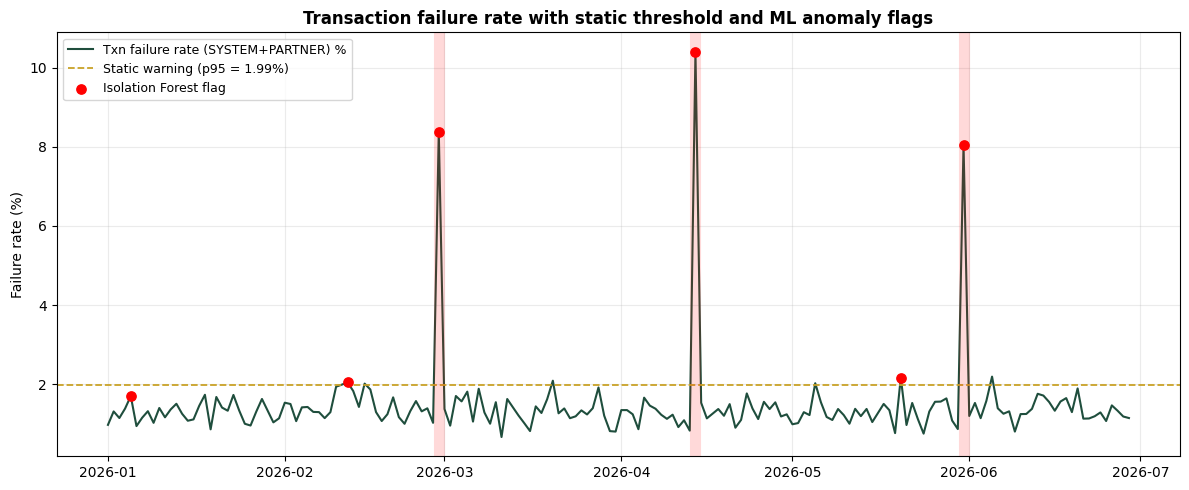

Chart saved -> anomaly_detection_chart.png


In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(feat["date"], feat["fail_rate_pct"],
        color="#1f4e3d", lw=1.5, label="Txn failure rate (SYSTEM+PARTNER) %")

thr = threshold_p95(df["fail_rate_pct"])
ax.axhline(thr, color="#c9a227", ls="--", lw=1.3,
           label=f"Static warning (p95 = {thr}%)")

# mark ground-truth outages
for d in GROUND_TRUTH:
    ax.axvline(d, color="red", alpha=0.15, lw=8)

# mark model flags
ax.scatter(flagged["date"], flagged["fail_rate_pct"],
           color="red", zorder=5, s=45, label="Isolation Forest flag")

ax.set_title("Transaction failure rate with static threshold and ML anomaly flags",
             fontsize=12, weight="bold")
ax.set_ylabel("Failure rate (%)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("anomaly_detection_chart.png", dpi=130, bbox_inches="tight")
plt.show()
print("Chart saved -> anomaly_detection_chart.png")


In [39]:
# ------------------------------------------------------------------
# Export the KRI table (computed from SQL above) for Power BI.
# Power BI reads THIS file and applies its own RAG thresholds in DAX.
# KRIs are computed once, in SQL — not recomputed here.
#
# KRI3 note: raw logs are aggregated to daily counts, so a true
# per-user computation isn't possible here. KRI3 is a transparent
# PROXY from the SYSTEM failure share; in production it would come
# from session-level logs. (Stated in README.)
# ------------------------------------------------------------------
export = df[["date", "fail_rate_pct", "velocity", "kri3_users_3fails",
             "ekyc_dropoff_pct", "override_pct", "overdue_training_pct"]].copy()
export = export.rename(columns={
    "fail_rate_pct":        "KRI1_TxnFailureRate",
    "velocity":             "KRI2_FailureVelocity",
    "kri3_users_3fails":    "KRI3_Users3Fails",
    "ekyc_dropoff_pct":     "KRI4_eKYCDropoff",
    "override_pct":         "KRI5_ManualOverride",
    "overdue_training_pct": "KRI6_OverdueTraining",
})
export = export[["date", "KRI1_TxnFailureRate", "KRI2_FailureVelocity",
                 "KRI3_Users3Fails", "KRI4_eKYCDropoff",
                 "KRI5_ManualOverride", "KRI6_OverdueTraining"]]
export.to_csv("../dashboard/kri_from_sql.csv", index=False)
print("Exported KRI table (6 KRIs) -> ../dashboard/kri_from_sql.csv")
print(export.tail(3))

Exported KRI table (6 KRIs) -> ../dashboard/kri_from_sql.csv
          date  KRI1_TxnFailureRate  KRI2_FailureVelocity  KRI3_Users3Fails  \
177 2026-06-27                1.331                  0.91             0.366   
178 2026-06-28                1.184                  0.89             0.440   
179 2026-06-29                1.145                  0.97             0.545   

     KRI4_eKYCDropoff  KRI5_ManualOverride  KRI6_OverdueTraining  
177             49.55                0.115                 14.98  
178             45.95                0.249                 15.00  
179             43.44                0.239                 15.00  


## Summary

- Six KRIs computed via auditable SQL over synthetic logs.
- Static thresholds set by the p95 / baseline+2σ rule (reproducible).
- Isolation Forest scores the **multivariate** daily pattern, catching
  the planted SYSTEM outages.
- Validation by synthetic-anomaly injection gives a measurable **recall**;
  error analysis separates seasonal noise from genuine signal.

*All figures illustrative — synthetic data only.*
